## Bkg plots: using coffea-casa

In [1]:
#### python
import os
import sys
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
import coffea.util
from matplotlib.colors import LogNorm
from coffea.processor import accumulate
import mplhep as hep
from helpers import merge_bkg

In [2]:
# client = scaleout.make_dask_client("tls://localhost:8786")
# client

In [3]:
vr = "24a"
nfiles = 3
sig2mu = [
    "2Mu2E_500GeV_0p25GeV_0p004mm", "2Mu2E_500GeV_0p25GeV_0p04mm", "2Mu2E_500GeV_0p25GeV_0p4mm", "2Mu2E_500GeV_0p25GeV_2p0mm", "2Mu2E_500GeV_0p25GeV_4p0mm",
    "2Mu2E_500GeV_1p2GeV_0p019mm",  "2Mu2E_500GeV_1p2GeV_0p19mm",  "2Mu2E_500GeV_1p2GeV_1p9mm",  "2Mu2E_500GeV_1p2GeV_9p6mm",  "2Mu2E_500GeV_1p2GeV_19p0mm",
    "2Mu2E_500GeV_5p0GeV_0p08mm",   "2Mu2E_500GeV_5p0GeV_0p08mm",  "2Mu2E_500GeV_5p0GeV_8p0mm",  "2Mu2E_500GeV_5p0GeV_40p0mm", "2Mu2E_500GeV_5p0GeV_80p0mm",
    "2Mu2E_200GeV_1p2GeV_4p8mm",    "2Mu2E_800GeV_1p2GeV_1p2mm",   "2Mu2E_1000GeV_1p2GeV_0p96mm",
]

tmulxy1 = ["2Mu2E_500GeV_0p25GeV_0p004mm", "2Mu2E_500GeV_0p25GeV_0p04mm", "2Mu2E_500GeV_0p25GeV_0p4mm", "2Mu2E_500GeV_0p25GeV_2p0mm", "2Mu2E_500GeV_0p25GeV_4p0mm",]
tmulxy2 = ["2Mu2E_500GeV_1p2GeV_0p019mm",  "2Mu2E_500GeV_1p2GeV_0p19mm",  "2Mu2E_500GeV_1p2GeV_1p9mm",  "2Mu2E_500GeV_1p2GeV_9p6mm",  "2Mu2E_500GeV_1p2GeV_19p0mm",]


sig4mu = [
    "4Mu_500GeV_0p25GeV_0p004mm",  "4Mu_500GeV_0p25GeV_0p04mm",   "4Mu_500GeV_0p25GeV_0p4mm",   "4Mu_500GeV_0p25GeV_2p0mm",   "4Mu_500GeV_0p25GeV_4p0mm",
    "4Mu_500GeV_1p2GeV_0p019mm",   "4Mu_500GeV_1p2GeV_0p19mm",    "4Mu_500GeV_1p2GeV_1p9mm",    "4Mu_500GeV_1p2GeV_9p6mm",    "4Mu_500GeV_1p2GeV_19p0mm", 
    "4Mu_500GeV_5p0GeV_0p08mm",    "4Mu_500GeV_5p0GeV_0p8mm",     "4Mu_500GeV_5p0GeV_8p0mm",    "4Mu_500GeV_5p0GeV_40p0mm",   "4Mu_500GeV_5p0GeV_80p0mm",
    "4Mu_200GeV_1p2GeV_4p8mm",     "4Mu_800GeV_1p2GeV_1p2mm",     "4Mu_1000GeV_1p2GeV_0p96mm",
]

bkgttj = ["TTJets"]

bkgdyj1 = ["DYJetsToMuMu_M10to50",]
bkgdyj2 = ["DYJetsToMuMu_M50",]

bkgqcd1 = ["QCD_Pt15To20",]
bkgqcd2 = ["QCD_Pt20To30"]
bkgqcd3 = ["QCD_Pt30To50",]
bkgqcd4 = ["QCD_Pt50To80"]
bkgqcd5 = ["QCD_Pt80To120"]
bkgqcd6 = ["QCD_Pt120To170"]
bkgqcd7 = ["QCD_Pt170To300",]
bkgqcd8 = ["QCD_Pt300To470"]
bkgqcd9 = ["QCD_Pt470To600"]
bkgqcd10 = ["QCD_Pt600To800"]
bkgqcd11 = ["QCD_Pt800To1000",] 
bkgqcd12 = ["QCD_Pt1000"]



channels = ["baseNoLj",
            "bkg_iso",
            "bkg_iso_disp",
            "bkg_iso_disp_2lj",
            "bkg_iso_disp_2lj_2mu2e",
            "bkg_iso_disp_2lj_4mu",
            "bkg_iso_disp_2lj_2mu2e_dphi",
           ]

In [4]:
runner = processor.Runner(
    # executor=processor.FuturesExecutor(),              # for testing locally
    executor=processor.IterativeExecutor(),              # for testing locally
    # executor=processor.DaskExecutor(client=client),    # for dask
    # schema=NanoAODSchema,
    schema = llpnanoaodschema.LLPNanoAODSchema,
    # maxchunks=1,
    skipbadfiles=True,
   
)

p = sidm_processor.SidmProcessor(
    channels,
    ["BKG_study"],
    unweighted_hist=True, verbose=False
    # verbose=True,
)

In [5]:
# process 2mu2e
fileset2mu1 = utilities.make_fileset(tmulxy1, "llpNanoAOD_v2", max_files = nfiles, location_cfg="signal_2mu2e_v10.yaml")
out2mu1 = runner.run(fileset2mu1, treename="Events", processor_instance=p)
out2mu1 = out2mu1["out"]
coffea.util.save(out2mu1, "outputs/bkg_" + vr + "_2mu1.coffea")

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: invalid value 
encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))

...

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

2Mu2E_500GeV_0p25GeV_0p004mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_500GeV_0p25GeV_0p04mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_500GeV_0p25GeV_0p4mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_500GeV_0p25GeV_2p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_500GeV_0p25GeV_4p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb


In [6]:
objs

NameError: name 'objs' is not defined

In [ ]:
#process 4mu
fileset4mu = utilities.make_fileset(sig4mu, "llpNanoAOD_v2", max_files = nfiles, location_cfg="signal_4mu_v10.yaml")
out4mu = runner.run(fileset4mu, treename="Events", processor_instance=p)
out4mu = out4mu["out"]
coffea.util.save(out4mu, "outputs/bkg_"+ vr + "_4mu.coffea")

In [ ]:
# Process ttj
filesetttj = utilities.make_fileset(bkgttj, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
outttj     = runner.run(filesetttj, treename="Events", processor_instance=p)
outttj     = outttj["out"]
coffea.util.save(outttj, "outputs/bkg_" + vr + "_ttj.coffea")

In [ ]:
# process DYJ
filesetdyj1 = utilities.make_fileset(bkgdyj1, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
outdyj1     = runner.run(filesetdyj1, treename="Events", processor_instance=p)
outdyj1     = outdyj1["out"]
coffea.util.save(outdyj1, "outputs/bkg_" + vr + "_dyj1.coffea")

In [ ]:
# process DYJ
filesetdyj2 = utilities.make_fileset(bkgdyj2, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
outdyj2     = runner.run(filesetdyj2, treename="Events", processor_instance=p)
outdyj2     = outdyj2["out"]
coffea.util.save(outdyj2, "outputs/bkg_" + vr + "_dyj2.coffea")

In [ ]:
# process qcd1
filesetqcd1    = utilities.make_fileset(bkgqcd1, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
outqcd1        = runner.run(filesetqcd1, treename="Events", processor_instance=p)
outqcd1        = outqcd1["out"]
coffea.util.save(outqcd1, "outputs/bkg_" + vr + "_qcd1.coffea")

In [ ]:
# process qcd2
filesetqcd2    = utilities.make_fileset(bkgqcd2, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
outqcd2        = runner.run(filesetqcd2, treename="Events", processor_instance=p)
outqcd2        = outqcd2["out"]
coffea.util.save(outqcd2, "outputs/bkg_" + vr + "_qcd2.coffea")

In [ ]:
# process qcd3
filesetqcd3    = utilities.make_fileset(bkgqcd3, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
outqcd3        = runner.run(filesetqcd3, treename="Events", processor_instance=p)
outqcd3        = outqcd3["out"]
coffea.util.save(outqcd3, "outputs/bkg_" + vr + "_qcd3.coffea")

In [ ]:
# process qcd4
filesetqcd4    = utilities.make_fileset(bkgqcd4, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
outqcd4        = runner.run(filesetqcd4, treename="Events", processor_instance=p)
outqcd4        = outqcd4["out"]
coffea.util.save(outqcd4, "outputs/bkg_" + vr + "_qcd4.coffea")

In [ ]:
# process qcd5
filesetqcd5    = utilities.make_fileset(bkgqcd5, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
outqcd5        = runner.run(filesetqcd5, treename="Events", processor_instance=p)
outqcd5        = outqcd5["out"]
coffea.util.save(outqcd5, "outputs/bkg_" + vr + "_qcd5.coffea")

In [ ]:
# process qcd6
filesetqcd6    = utilities.make_fileset(bkgqcd6, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
outqcd6        = runner.run(filesetqcd6, treename="Events", processor_instance=p)
outqcd6        = outqcd6["out"]
coffea.util.save(outqcd6, "outputs/bkg_" + vr + "_qcd6.coffea")

In [ ]:
# process qcd7
filesetqcd7    = utilities.make_fileset(bkgqcd7, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
outqcd7        = runner.run(filesetqcd7, treename="Events", processor_instance=p)
outqcd7        = outqcd7["out"]
coffea.util.save(outqcd7, "outputs/bkg_" + vr + "_qcd7.coffea")

In [ ]:
# process qcd8
filesetqcd8    = utilities.make_fileset(bkgqcd8, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
outqcd8        = runner.run(filesetqcd8, treename="Events", processor_instance=p)
outqcd8        = outqcd8["out"]
coffea.util.save(outqcd8, "outputs/bkg_" + vr + "_qcd8.coffea")

In [ ]:
# process qcd10
filesetqcd9    = utilities.make_fileset(bkgqcd9, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
outqcd9        = runner.run(filesetqcd9, treename="Events", processor_instance=p)
outqcd9        = outqcd9["out"]
coffea.util.save(outqcd9, "outputs/bkg_" + vr + "_qcd9.coffea")

In [ ]:
# process qcd2
filesetqcd10    = utilities.make_fileset(bkgqcd10, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
outqcd10        = runner.run(filesetqcd10, treename="Events", processor_instance=p)
outqcd10        = outqcd10["out"]
coffea.util.save(outqcd10, "outputs/bkg_" + vr + "_qcd10.coffea")

In [ ]:
# process qcd2
filesetqcd11    = utilities.make_fileset(bkgqcd11, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
outqcd11        = runner.run(filesetqcd11, treename="Events", processor_instance=p)
outqcd11        = outqcd11["out"]
coffea.util.save(outqcd11, "outputs/bkg_" + vr + "_qcd11.coffea")

In [ ]:
# process qcd2
filesetqcd12    = utilities.make_fileset(bkgqcd12, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
outqcd12        = runner.run(filesetqcd12, treename="Events", processor_instance=p)
outqcd12        = outqcd12["out"]
coffea.util.save(outqcd12, "outputs/bkg_" + vr + "_qcd12.coffea")

In [ ]:
objs

In [ ]:
# out_all = out_2mu | out_4mu | out_dyj | out_ttj | out_qcd | out_ocd
# outall = {
#     **out2mu, 
#     **out4mu,
#     **outdyj,
#     **outttj,
#     **outqcd, 
#     **outocd,
# }
# coffea.util.save(out_all, f"outputs/bkg_{vr}.coffea")

# Start plottong

In [7]:
out2mu = coffea.util.load(f"outputs/bkg_24a_2mu1.coffea")
outdyj = coffea.util.load(f"outputs/bkg_24_dyj.coffea")
outttj = coffea.util.load(f"outputs/bkg_24_ttj.coffea")
outqcd = coffea.util.load(f"outputs/bkg_24_qcd.coffea")
outocd = coffea.util.load(f"outputs/bkg_24_ocd.coffea")

outall = {**out2mu, 
          **outttj,
          **outdyj,
          **outqcd, **outocd,
         }

coffea.util.save(outall, f"outputs/bkg_24a.coffea")

In [8]:
vr = "24a"
output = coffea.util.load(f"outputs/bkg_{vr}.coffea")

In [9]:
h = output["TTJets"]["hists"]["lj0_pt"]
print(h.axes)

(StrCategory(['baseNoLj', 'bkg_iso', 'bkg_iso_disp', 'bkg_iso_disp_2lj_2mu2e', 'bkg_iso_disp_2lj_4mu', 'bkg_iso_disp_2lj_2mu2e_dphi', 'bkg_iso_disp_2lj_4mu_dphi'], name='channel'), Regular(100, 0, 400, name='lj0_pt', label='Leading lepton jet pT [GeV]'))


In [10]:
tmulxy1 = [
    "2Mu2E_500GeV_0p25GeV_0p004mm", "2Mu2E_500GeV_0p25GeV_0p04mm", "2Mu2E_500GeV_0p25GeV_0p4mm", "2Mu2E_500GeV_0p25GeV_2p0mm", "2Mu2E_500GeV_0p25GeV_4p0mm"]
bkgttj = ["TTJets"]

bkgdyj = ["DYJetsToMuMu_M10to50", "DYJetsToMuMu_M50"]

bkgqcd = ["QCD_Pt15To20", "QCD_Pt20To30", "QCD_Pt30To50", "QCD_Pt50To80", "QCD_Pt80To120", "QCD_Pt120To170", "QCD_Pt170To300", "QCD_Pt300To470", 
          "QCD_Pt470To600", "QCD_Pt600To800",
          # "QCD_Pt800To1000",
          "QCD_Pt1000"]

channels = ["baseNoLj",
            "bkg_iso",
            "bkg_iso_disp",
            "bkg_iso_disp_2lj_2mu2e",
            "bkg_iso_disp_2lj_2mu2e_dphi",
           ]

ch1 = channels[0]
ch2 = channels[1]
ch3 = channels[2]
ch4 = channels[3]
ch5 = channels[4]
# ch6 = channels[5]

cha2name = ["nosel", "Iso", "Disp", "2mu2e", r"$\Delta\Phi > 2$"]
cha2 = [ch1, ch2, ch3, ch4, ch5]

In [22]:
histoplot = ["lj_lj_invmass"]
cha2 = [ch1, ch2, ch3, ch4, ch5]
lablxy1 = ["0p3", "3p0", "30", "150", "300"]
colmx=["black", "darkviolet", "navy", "magenta", "darkorange", "darkblue"]

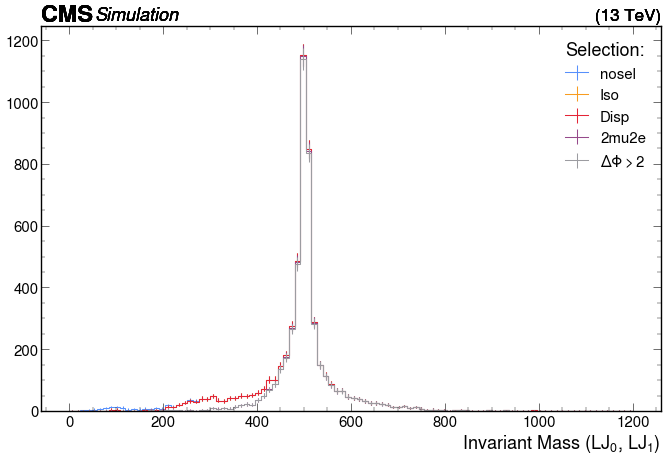

In [28]:
#plot process only
for ik, htp in enumerate(histoplot):
    plt.subplots(1, 1, figsize=(16, 10))
    for ij, ch in enumerate(cha2):
        utilities.plot(output[tmulxy1[2]]["hists"][htp][ch, :], label = cha2name[ij])
    # plt.title(name2mu[ik])
    # plt.ylabel("Events")
    # plt.yscale("log")
    plt.legend(title=r"Selection:", alignment="left", loc=0)
    # print("clean_plots/ch5_bkg_{vr}_lxy_{ht}_.pdf")
#     plt.savefig(f"clean_plots/ch5_bkg_{vr}_lxy_{ht}_.pdf", bbox_inches="tight", dpi=300)

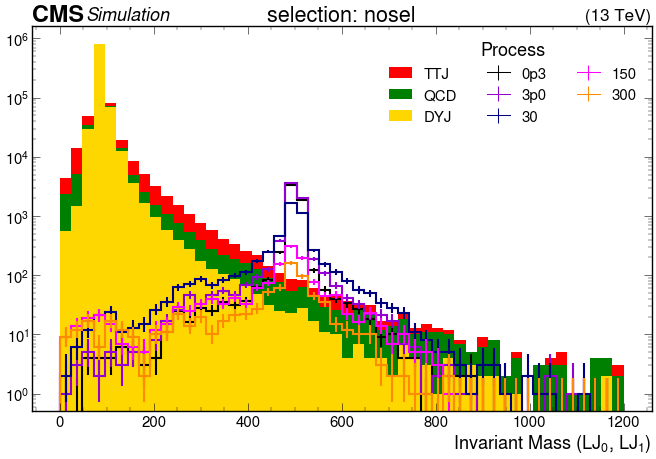

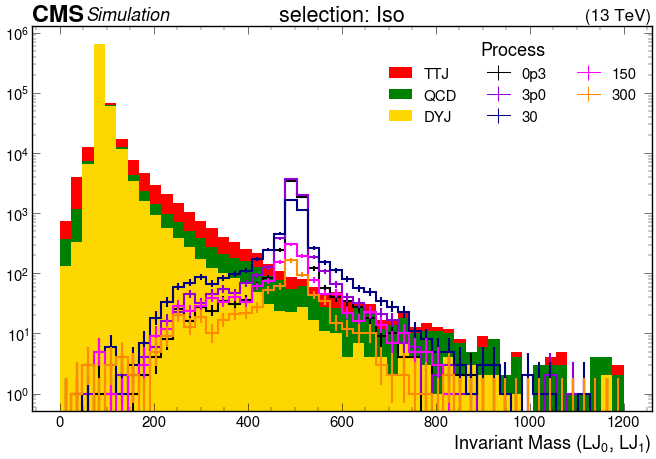

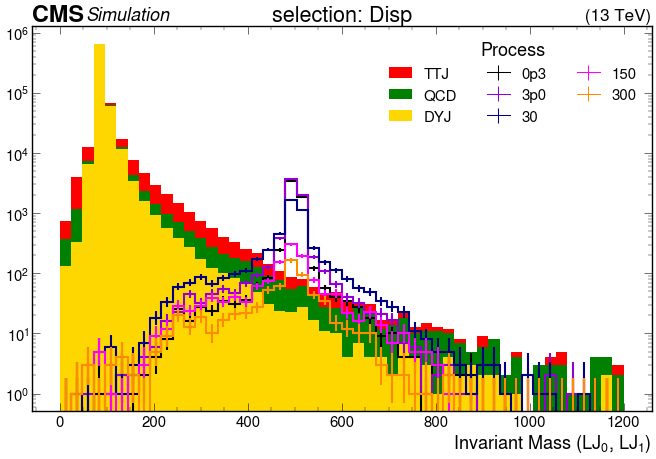

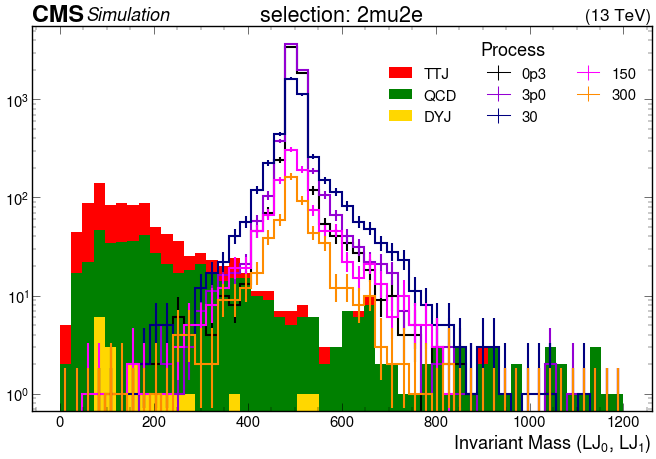

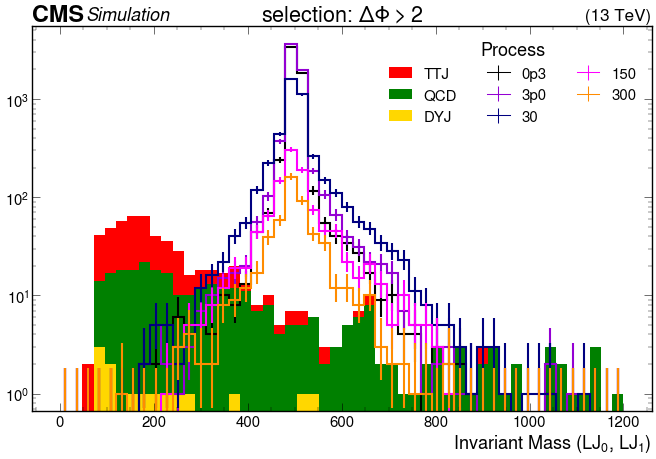

In [17]:
###################################################
####### Stacking Backgrounds diff channels for mxx ###
###################################################

for htp in histoplot:  
    for ic, ch in enumerate(cha2):
        
        fig, ax = plt.subplots(figsize=(16,10))
        
        DYJ = merge_bkg(output, bkgdyj, htp, ch)
        QCD = merge_bkg(output, bkgqcd, htp, ch)
        TTJ = merge_bkg(output, bkgttj, htp, ch)
        
        # Backgrounds
        hep.histplot([DYJ, QCD, TTJ],     stack=True,     histtype="fill",     color=["gold", "green", "red"],     label=["DYJ", "QCD", "TTJ"],     ax=ax, )
        
        # Signal        
        for ix, sss in enumerate(tmulxy1):
            hep.histplot(output[sss]["hists"][htp][ch, ::2j],  color=colmx[ix], label=lablxy1[ix], histtype="step", linewidth=3, ax=ax)
        hep.cms.label(data=False, lumi=None, com=13, ax=ax)
        # ax.set_ylim(1, 1000000)
        # ax.yscale(1,10000)
        ax.set_yscale("log")
        ax.legend(title="Process", ncol=3)
        plt.title(f"selection: {cha2name[ic]}")
        # plt.savefig(f"clean_plots/fin_bkg_stack_{vr}_{ht}_{cha2name[ic]}_mxx.pdf", bbox_inches="tight", dpi=300)